In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [ ]:
data=pd.read_csv('/content/sample_data/car_data.csv')
print('Data Loaded Successfully')
data.head(10)

Data Loaded Successfully


,Horsepower,Weight,Engine_Size,Price
0,130,3504,2.5,20000
1,165,3693,3.0,25000
2,150,3436,2.8,23000
3,140,3449,2.2,21000
4,198,4341,3.8,32000
5,220,4354,4.0,35000
6,215,4732,4.5,37000
7,225,4380,4.6,39000
8,190,3850,3.3,31000
9,170,3560,2.9,27000


In [ ]:
X=data[['Horsepower','Weight','Engine_Size']].values
y=data['Price'].values
# X=tf.constant(X,dtype=tf.float32)
#y=tf.constant(y,dtype=tf.float32)
#print('Feature Tensor Shape: ',X.shape)
#print('Label Tensor Shape: ',y.shape)

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=4)

In [ ]:
model=tf.keras.Sequential([tf.keras.layers.Dense(16,activation='relu'),
                           tf.keras.layers.Dense(8,activation='relu'),
                           tf.keras.layers.Dense(1)])
model.compile(optimizer='adam',loss='mse',metrics=['mae'])
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history=model.fit(X,y,epochs=200,verbose=0)


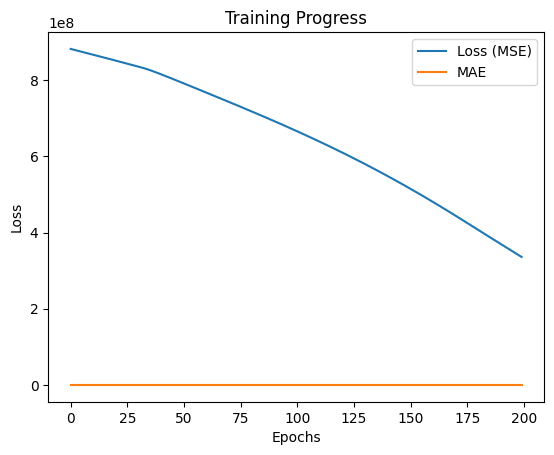

In [ ]:
plt.plot(history.history['loss'],label='Loss (MSE)')
plt.plot(history.history['mae'],label='MAE')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Progress')
plt.legend()
plt.show()

In [ ]:
test_sample=np.array([[160,3550,2.5]])
prediction=model.predict(test_sample)
print('Predicted price',prediction[0][0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
Predicted price 10410.857
